In [1]:
import matplotlib.pyplot as plt

In [2]:
x1=[0,0,1,1]
x2=[0,1,0,1]
y=[0,1,1,0]

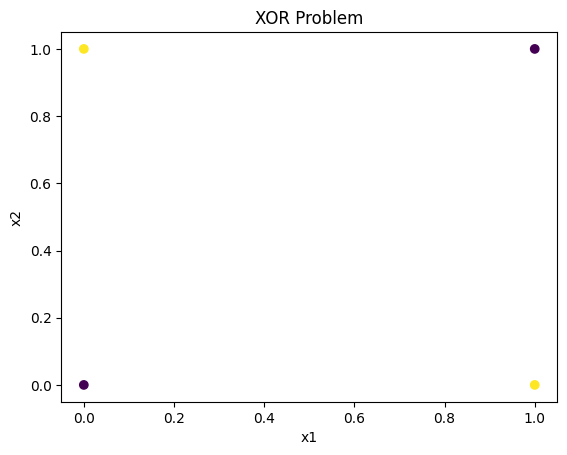

In [3]:
plt.scatter(x1,x2,c=y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR Problem')
plt.show()

In [4]:
from sklearn.linear_model import LogisticRegression
import numpy as np

In [5]:
np.array([x1, x2]).T

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [6]:
model = LogisticRegression()
model.fit(np.array([x1, x2]).T, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
accuracy = model.score(np.array([x1, x2]).T, y)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.50


# XOR problem — ANN with TensorFlow
This notebook adds a small fully-connected neural network implemented with TensorFlow/Keras to solve the XOR problem. It trains on the 4 input patterns and shows predictions and training curves.

In [8]:
# Imports and data setup
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (4, 2) y shape: (4, 1)


In [9]:
# Build the model
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = model.fit(X, y, epochs=500, verbose=0)
print('Final loss:', history.history['loss'][-1])
print('Final accuracy:', history.history['accuracy'][-1])

Final loss: 0.11567921936511993
Final accuracy: 1.0


In [11]:
# Evaluate and predict
preds = model.predict(X)
print('Raw predictions:')
print(preds)
print('Rounded predictions:')
print((preds>0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Raw predictions:
[[0.23382224]
 [0.945649  ]
 [0.92881465]
 [0.06250332]]
Rounded predictions:
[[0]
 [1]
 [1]
 [0]]


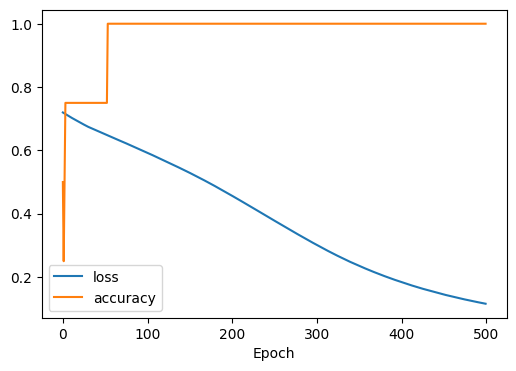

In [12]:
# Training curves
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# ANN for XOR (TensorFlow/Keras) and plots
This cell group builds, trains and plots an ANN for the XOR problem using TensorFlow. It shows both training curves and a decision boundary.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

Final loss: 0.08710479736328125
Final accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Raw preds: [0.16  0.906 0.975 0.047]
Rounded preds: [0 1 1 0]


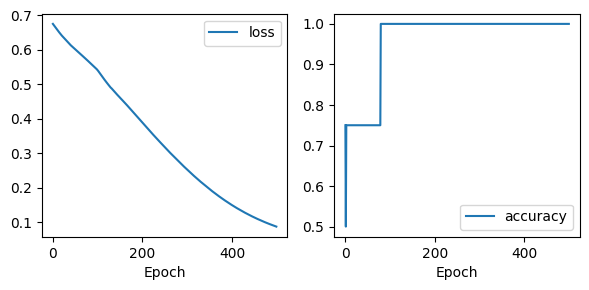

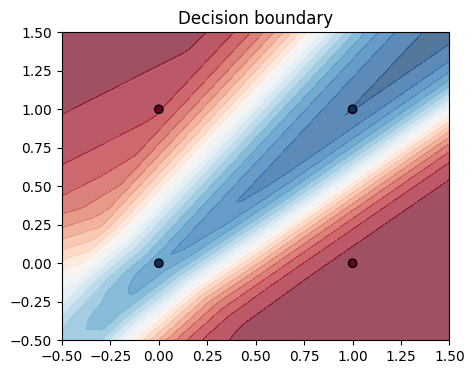

In [13]:
# Imports, data, model, training and plotting
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

# Build model
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
model.summary()

# Train
history = model.fit(X, y, epochs=500, verbose=0)
print('Final loss:', history.history['loss'][-1])
print('Final accuracy:', history.history['accuracy'][-1])

# Predictions
preds = model.predict(X)
print('Raw preds:', np.round(preds,3).ravel())
print('Rounded preds:', (preds>0.5).astype(int).ravel())

# Plot training curves
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# Decision boundary
xx = np.linspace(-0.5,1.5,200)
yy = np.linspace(-0.5,1.5,200)
grid = np.array([[a,b] for a in xx for b in yy], dtype=np.float32)
Z = model.predict(grid, verbose=0).reshape(len(xx), len(yy))
plt.figure(figsize=(5,4))
plt.contourf(xx, yy, Z.T, levels=20, cmap='RdBu_r', alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdBu_r', edgecolors='k')
plt.title('Decision boundary')
plt.xlim(-0.5,1.5)
plt.ylim(-0.5,1.5)
plt.show()